# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [72]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
#from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from keras.layers import Conv2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.layers import Dropout

In [73]:
#load the data set
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [74]:
print(np.min(X_train[0]), np.max(X_train[0]))

0.0 1.0


In [75]:
#Inspect the shapes of the training and test sets to confirm their size and structure.
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [76]:
# Convert the labels to one-hot encoded format if necessary. 
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"One-hot encoded label shape: {y_train_cat.shape}") 

One-hot encoded label shape: (60000, 10)


In [77]:
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [78]:
for c in range(10):
    idx = np.where(y_train == c)[0][0]
    print(class_names[c])
    print("Encoded:", y_train_cat[idx])
    print()

T-shirt/top
Encoded: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Trouser
Encoded: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]

Pullover
Encoded: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]

Dress
Encoded: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]

Coat
Encoded: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]

Sandal
Encoded: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

Shirt
Encoded: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

Sneaker
Encoded: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

Bag
Encoded: [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]

Ankle boot
Encoded: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]



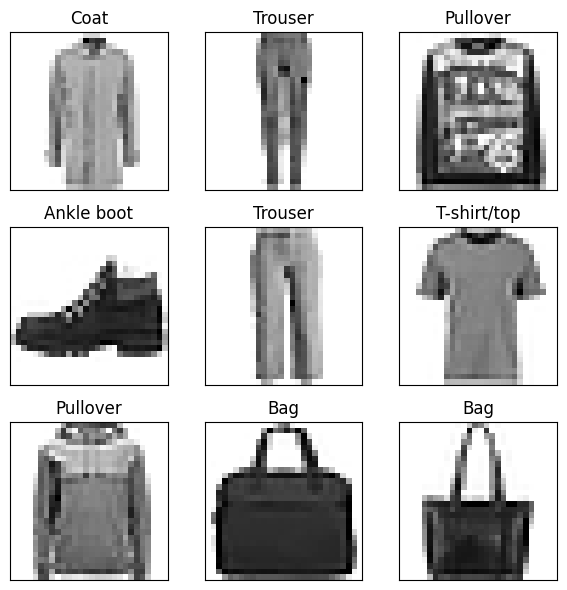

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Select 9 random indices
random_indices = np.random.choice(len(X_train), 9, replace=False)

# Create 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.binary)
    ax.set_title(class_names[y_train[random_indices[i]]])

    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


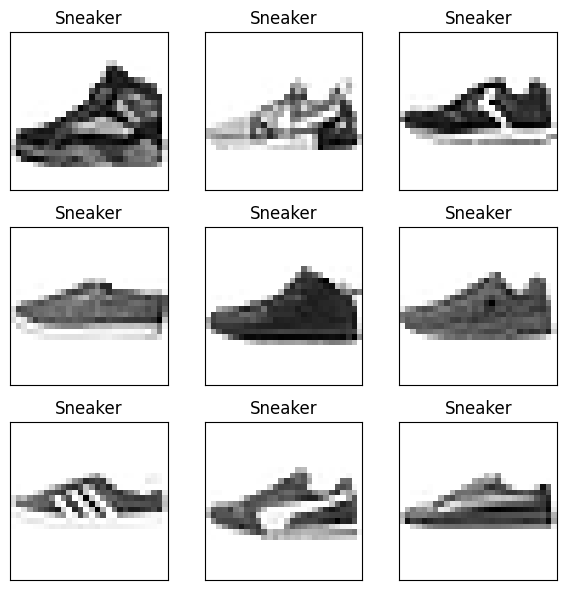

In [57]:
# Choose class index (change this to any class 0–9)
target_class = 7   # Sneaker

# Get indices of that class
class_indices = np.where(y_train == target_class)[0]

# Pick 9 random ones
random_indices = np.random.choice(class_indices, 9, replace=False)

# Plot
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.binary)
    ax.set_title(class_names[target_class])

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


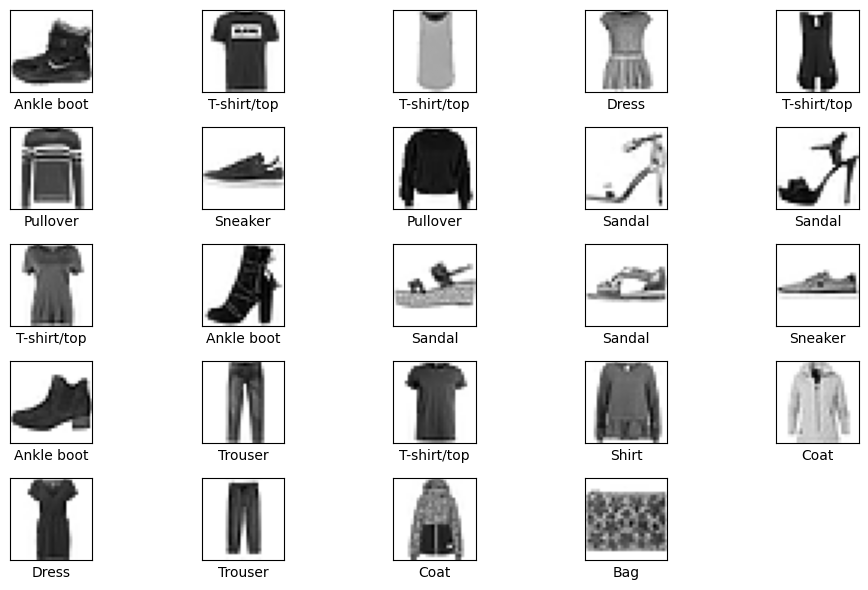

In [80]:
#class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

#  Verify the data looks as expected

plt.figure(figsize=(10, 6))
for i in range(24):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**
The Fashion MNIST dataset looks as expected. It contains 60,000 training images and 10000
test images. It contains grayscale 28×28 images for 10 clothing categories, 
and the labels match the classes. 

The image quality is consistent but fairly low resolution, 
so some items (like shirts and coats) look similar, which could make classification harder. 
Overall, the dataset is clean and suitable for training.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [59]:
print(X_train.shape)
print(y_train_cat.shape)


(60000, 28, 28)
(60000, 10)


In [81]:
###------------------------------------------------------------
###                2.   Baseline Model
###----------------------------------------------------

model_basline = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
# Input layer (28x28 → 784 neurons after flattening)
model_basline.add(Flatten(input_shape=(28,28)))   # Flatten the 28x28 images into a 1D vector of 784 pixels
model_basline.add(Dense(10, activation='linear'))

# Compile
model_basline.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # categorical cross-entropy loss function for multi-class classification
    metrics=['accuracy']
)

# Train the model with `model.fit()`- 10 epochs to see the baseline performance
history = model_basline.fit(
    X_train, y_train_cat,
    epochs=5,
    validation_split=0.2,
    verbose=1
)
# Evaluate
base_loss, base_acc = model_basline.evaluate(X_test, y_test_cat, verbose=0)
print(f"Baseline Test Accuracy: {base_acc:.4f}")

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.2086 - loss: 9.8458 - val_accuracy: 0.2102 - val_loss: 11.1378
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2161 - loss: 10.2421 - val_accuracy: 0.2299 - val_loss: 9.6200
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2242 - loss: 10.7753 - val_accuracy: 0.2245 - val_loss: 10.7280
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2241 - loss: 10.7820 - val_accuracy: 0.2245 - val_loss: 10.7280
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.2241 - loss: 10.7820 - val_accuracy: 0.2245 - val_loss: 10.7280
Baseline Test Accuracy: 0.2269


In [82]:
model_basline.summary()

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_30 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,552 (92.00 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,702 (61.34 KB)

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**
The baseline model is liner model typically achieves 23% accuracy.

The baseline model did not perform well. This is because spatial information like edges and 
forms are eliminated when the model flattens the images into vectors. Because cloths 
recognition relies on visual structure, the model's accuracy is limited because it 
is unable to catch crucial elements.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [83]:
#####----------------------------------------------------------------
# 3.                      SIMPLE CNN MODLE
#######----------------------------------------------------------------

# Prepare data 
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test.reshape(-1, 28, 28, 1)

# Build CNN  
model_cnn = Sequential([
    #  INPUT + HIDDEN (Convolution layer )
    Conv2D(32, (3,3),
           activation='relu',
           strides=1,
           padding='same',
           input_shape=(28,28,1)), # receives image
    # Conv layer2 
    # Conv2D(64, (3,3), activation='relu', strides=2, padding='same'),

    #   HIDDEN (feature processing) -Flatten ,classifier
    Flatten(),                             ## converts feature maps to a vector
    Dense(64, activation='relu'),          ## hidden layer
    Dense(10, activation='softmax')        ## Output layer for 10 classes
])
#Compile the model with an appropriate loss function and metrics for a multi-class classification problem 
model_cnn.compile(
    optimizer='adam',                    #  ADAM (SGD algorithm less accu)
    loss='categorical_crossentropy',      # how error is calculated (cross-entropy)  
    metrics=['accuracy']
)
# Train 
history = model_cnn.fit(                  # history store the data lose, accuracy, validation loss, accuracy
    X_train_cnn, y_train_cat,
    epochs=5,      # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2,
    verbose=1
)
# Evaluate
model_cnn_loss, model_cnn_acc = model_cnn.evaluate(X_test_cnn, y_test_cat)
print("CNN accuracy:", model_cnn_acc)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8614 - loss: 0.3897 - val_accuracy: 0.8722 - val_loss: 0.3501
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9033 - loss: 0.2629 - val_accuracy: 0.8988 - val_loss: 0.2811
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9227 - loss: 0.2071 - val_accuracy: 0.8929 - val_loss: 0.3094
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9373 - loss: 0.1686 - val_accuracy: 0.9028 - val_loss: 0.2911
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9501 - loss: 0.1354 - val_accuracy: 0.9057 - val_loss: 0.2865
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9023 - loss: 0.3059
CNN accuracy: 0.9023000001907349


In [84]:
loss, accuracy = model_cnn.evaluate(X_test_cnn, y_test_cat)
print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9023 - loss: 0.3059
Loss:     0.31
Accuracy: 90.23%


In [85]:
print(model_cnn.summary())

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_31 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,820,000 (18.39 MB)

 Trainable params: 1,606,666 (6.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,213,334 (12.26 MB)

None


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**
CNN is 90 % accuracy performance was significantly better than '
the baseline's. 

The model was compiled using the Adam optimizer, categorical cross-entropy loss, 
and accuracy as the evaluation metric. Categorical cross-entropy is appropriate 
for multi-class classification when labels are one-hot encoded, and accuracy 
measures the proportion of correctly classified images.

Layers preserve the images' 2D structure while learning valuable visual 
characteristics like textures and forms, which is why CNN significantly 
increased accuracy.

As a result, the model can more successfully run between different types of algorithm.



# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [86]:
#----------------------------------------------------------------------------------
# 4.       Designing and Running Controlled Experiments -
#                          A. Test Hyperparameters
#--------------------------------------------------------------------------------------------
results = []
filters_list = [32, 64, 128]

In [87]:
#--------------------------------------------------------------------------------------------
# B. Test presence or absence of regularization
#--------------------------------------------------------------------------------------------
for f in filters_list:
    # model without dropout
    m1 = Sequential([
        Conv2D(f,(3,3),activation="relu",input_shape=(28,28,1)),
        Flatten(),
        Dense(64,activation="relu"),
        Dense(10,activation="softmax")
    ])
    m1.compile(optimizer="adam",
               loss="categorical_crossentropy",
               metrics=["accuracy"])
    
    m1.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, verbose=1)
    
    acc1 = m1.evaluate(X_test_cnn, y_test_cat, verbose=1)[1]
    results.append((f,"No Dropout",acc1))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8613 - loss: 0.3864
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9064 - loss: 0.2578
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9240 - loss: 0.2079
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9366 - loss: 0.1683
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9493 - loss: 0.1374
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8968 - loss: 0.3054
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.8628 - loss: 0.3875
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.9054 - loss: 0.2570
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9250 - loss: 0.2055
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9367 - loss: 0.1683
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9494 - loss: 0.1367
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/

In [88]:
#-------------------------------------------------------------------
###                        Model with dropout 
#-------------------------------------------------------------------
for f in filters_list:
    m2 = Sequential([
        Conv2D(f,(3,3),activation="relu",input_shape=(28,28,1)),
        #kernel_regularizer=l2(0.001),         # L2 regularization
        Flatten(),
        Dense(64,activation="relu"),
        Dropout(0.5),
        #kernel_regularizer=l2(0.001)),        # L2 regularization
        Dense(10,activation="softmax")
    ])
    m2.compile(optimizer="adam",
               loss="categorical_crossentropy",
               metrics=["accuracy"])

    m2.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, verbose=1)
    acc2 = m2.evaluate(X_test_cnn, y_test_cat, verbose=1)[1]

    results.append((f,"With Dropout",acc2))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7953 - loss: 0.5808
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8505 - loss: 0.4104
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8664 - loss: 0.3688
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8782 - loss: 0.3320
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8865 - loss: 0.3070
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8949 - loss: 0.2866
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.7660 - loss: 0.6480
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.8418 - loss: 0.4394
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.8593 - loss: 0.3871
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8694 - loss: 0.3538
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8778 - loss: 0.3256
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [89]:
# Results
for r in results:
    print("Filters:", r[0], "|", r[1], "| Accuracy:", r[2])

Filters: 32 | No Dropout | Accuracy: 0.8967999815940857
Filters: 64 | No Dropout | Accuracy: 0.9035000205039978
Filters: 128 | No Dropout | Accuracy: 0.9057000279426575
Filters: 32 | With Dropout | Accuracy: 0.8949000239372253
Filters: 64 | With Dropout | Accuracy: 0.8912000060081482
Filters: 128 | With Dropout | Accuracy: 0.8991000056266785


In [90]:

# Convert experiment results list to dataframe
exp_df = pd.DataFrame(results, columns=["Filters","Regularization","Accuracy"])


# Helper function to safely fetch accuracy
def get_acc(df, f, reg):
    row = df[(df["Filters"]==f) & (df["Regularization"]==reg)]
    return row["Accuracy"].values[0] if len(row)>0 else None

# Build full comparison table
final_table = pd.DataFrame({
    "Model":[
        "Baseline (Linear)",
        "CNN (Main Model)",
        "Filter=32, No Dropout",
        "Filter=64, No Dropout",
        "Filter=128, No Dropout",
        "Filter=32, With Dropout",
        "Filter=64, With Dropout",
        "Filter=128, With Dropout"
    ],
    
    "Test Accuracy":[
        base_acc,
        model_cnn_acc,
        get_acc(exp_df,32,"No Dropout"),
        get_acc(exp_df,64,"No Dropout"),
        get_acc(exp_df,128,"No Dropout"),
        get_acc(exp_df,32,"With Dropout"),
        get_acc(exp_df,64,"With Dropout"),
        get_acc(exp_df,128,"With Dropout"),
    ]
})

# Compute improvement vs baseline
baseline = final_table.iloc[0]["Test Accuracy"]
final_table["Improvement (%)"] = ((final_table["Test Accuracy"]-baseline)*100).round(2)

# Improvement vs baseline
baseline = final_table.iloc[0]["Test Accuracy"]
final_table["Improvement (%)"] = ((final_table["Test Accuracy"]-baseline)*100).round(2)

display(final_table)


,Model,Test Accuracy,Improvement (%)
0,Baseline (Linear),0.2269,0.00
1,CNN (Main Model),0.9023,67.54
2,"Filter=32, No Dropout",0.8968,66.99
3,"Filter=64, No Dropout",0.9035,67.66
4,"Filter=128, No Dropout",0.9057,67.88
5,"Filter=32, With Dropout",0.8949,66.80
6,"Filter=64, With Dropout",0.8912,66.43
7,"Filter=128, With Dropout",0.8991,67.22


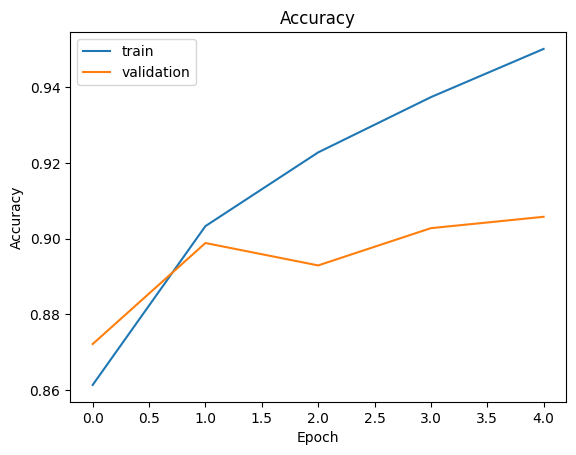

In [91]:
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**
The model's ability to learn more image attributes led to a small 
improvement in performance when the number of filters was increased from 32 to 128. 
The slight improvement, meanwhile, indicates that even fewer filters 
performed not better. 

In this instance, a Dropout layer with a rate of 0.5, dropout did not enhance outcomes and marginally 
decreased accuracy, indicating that the model was not significantly overfitting.


The best model from the experiments was the CNN with 128 filters and no dropout, 
which achieved the highest test accuracy of about 0.9057.  

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [93]:
##-------------------------------------------------------------------
#  5.                  Build the final model
##----------------------------------------------------------------------
final_model = Sequential([
    Conv2D(128, (3, 3), activation='relu', input_shape=(28, 28, 1)),  #best 128 filter and no dropout
    Flatten(),
    Dense(64, activation='relu'),                 
    Dense(10, activation='softmax')
])
#  Compile
final_model.compile(optimizer='adam', 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])

# Train
final_model.fit(X_train_cnn, 
                y_train_cat, 
                epochs=5, 
                batch_size=32, 
                validation_split=0.2)


#  Evaluate
test_loss, test_acc = final_model.evaluate(X_test_cnn, y_test_cat)
print(f"\nFinal Model Test Accuracy: {test_acc:.4f}")

Epoch 1/5


c:\Users\amena\DSI\Deep_learning\deep-learning-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 38ms/step - accuracy: 0.8604 - loss: 0.3969 - val_accuracy: 0.8874 - val_loss: 0.3088
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.9035 - loss: 0.2620 - val_accuracy: 0.8966 - val_loss: 0.2792
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 50ms/step - accuracy: 0.9258 - loss: 0.2002 - val_accuracy: 0.8950 - val_loss: 0.2995
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 69s 46ms/step - accuracy: 0.9423 - loss: 0.1566 - val_accuracy: 0.9050 - val_loss: 0.2888
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 68s 46ms/step - accuracy: 0.9554 - loss: 0.1218 - val_accuracy: 0.9032 - val_loss: 0.3034
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8996 - loss: 0.3123

Final Model Test Accuracy: 0.8996


In [94]:
print(final_model.summary())

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 26, 26, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_38 (Flatten)            │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,619,360 (63.40 MB)

 Trainable params: 5,539,786 (21.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,079,574 (42.27 MB)

None


In [95]:
predictions = final_model.predict(X_test_cnn)
predictions[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([[4.8083416e-06, 2.7044074e-09, 9.3563887e-07, 8.1885158e-11,
        5.9267853e-09, 2.5324100e-06, 4.8582741e-08, 4.0757055e-05,
        1.6197700e-06, 9.9994934e-01],
       [7.3552648e-09, 3.1219753e-12, 9.9999857e-01, 1.5226866e-10,
        1.3892733e-07, 3.7123309e-14, 1.2657632e-06, 9.0059906e-15,
        1.2232888e-10, 2.8717354e-12],
       [7.1129808e-12, 1.0000000e+00, 1.1522117e-12, 8.9543109e-11,
        2.9062391e-12, 1.8364884e-18, 7.1415760e-14, 7.4591429e-17,
        2.2341906e-11, 1.7433740e-19],
       [2.8018898e-12, 1.0000000e+00, 1.9367434e-13, 2.0571543e-10,
        7.0789985e-11, 1.8029473e-18, 7.3885254e-14, 3.2668224e-17,
        3.6048377e-14, 1.8774738e-18],
       [7.1135426e-01, 2.0783018e-06, 1.2660838e-02, 6.0286526e-05,
        3.6141466e-02, 2.3957587e-06, 2.3975113e-01, 6.0575800e-08,
        2.7058240e-05, 4.6250355e-07]], dtype=float32)

NOTE :The model outputs a probability distribution across the 10 classes for each test 
image, and the predicted class is the one with the highest probability in each row

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model performed the baseline by a significant margin and outperformed the basic
CNN by a small incresed. 

The convolutional layers'  see the spatial features and apply enough filters to identify 
meaningful patterns accounts for its high performance. To increase accuracy even further.

If i have time perofemoerd adding another convolutional layer,testing different kernel sizes,
applying batch normalization trying smaller dropout values,using data augmentation to improve robustnes

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.